<a href="https://colab.research.google.com/github/RiyaRajKumari/ML-Mini-Project-of-Asteroid-hazard-prediction/blob/main/ML_project(Asteroid_hazard_prediction).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Preprocessing:-

Importing libraries and loading the dataset:-


In [ ]:
import pandas as pd
import numpy as np
# 1. Load Dataset
df = pd.read_csv(r"/content/nearest-earth-objects.csv")
df

,neo_id,name,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,orbiting_body,relative_velocity,miss_distance,is_hazardous
0,2162117,162117 (1998 SD15),19.140,0.394962,0.883161,Earth,71745.401048,5.814362e+07,False
1,2349507,349507 (2008 QY),18.500,0.530341,1.185878,Earth,109949.757148,5.580105e+07,True
2,2455415,455415 (2003 GA),21.450,0.136319,0.304818,Earth,24865.506798,6.720689e+07,False
3,3132126,(2002 PB),20.630,0.198863,0.444672,Earth,78890.076805,3.039644e+07,False
4,3557844,(2011 DW),22.700,0.076658,0.171412,Earth,56036.519484,6.311863e+07,False
...,...,...,...,...,...,...,...,...,...
338194,54403809,(2023 VS4),28.580,0.005112,0.011430,Earth,56646.985988,6.406548e+07,False
338195,54415298,(2023 XW5),28.690,0.004859,0.010865,Earth,21130.768947,2.948883e+07,False
338196,54454871,(2024 KJ7),21.919,0.109839,0.245607,Earth,11832.041031,5.346078e+07,False
338197,54456245,(2024 NE),23.887,0.044377,0.099229,Earth,56198.382733,5.184742e+06,False


Inspect the data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338199 entries, 0 to 338198
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   neo_id                  338199 non-null  int64  
 1   name                    338199 non-null  object 
 2   absolute_magnitude      338171 non-null  float64
 3   estimated_diameter_min  338171 non-null  float64
 4   estimated_diameter_max  338171 non-null  float64
 5   orbiting_body           338199 non-null  object 
 6   relative_velocity       338199 non-null  float64
 7   miss_distance           338199 non-null  float64
 8   is_hazardous            338199 non-null  bool   
dtypes: bool(1), float64(5), int64(1), object(2)
memory usage: 21.0+ MB


Check for missing values per column:-

In [ ]:
df.isnull().sum()

,0
neo_id,0
name,0
absolute_magnitude,28
estimated_diameter_min,28
estimated_diameter_max,28
orbiting_body,0
relative_velocity,0
miss_distance,0
is_hazardous,0


Checking for summaries like mean,median, min/max and quartiles:-

In [ ]:
df.describe()

,neo_id,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,relative_velocity,miss_distance
count,3.381990e+05,338171.000000,338171.000000,338171.000000,338199.000000,3.381990e+05
mean,1.759939e+07,22.932525,0.157812,0.352878,51060.662908,4.153535e+07
std,2.287225e+07,2.911216,0.313885,0.701869,26399.238435,2.077399e+07
min,2.000433e+06,9.250000,0.000511,0.001143,203.346433,6.745533e+03
25%,3.373980e+06,20.740000,0.025384,0.056760,30712.031471,2.494540e+07
50%,3.742127e+06,22.800000,0.073207,0.163697,47560.465474,4.332674e+07
75%,5.405374e+07,25.100000,0.189041,0.422708,66673.820614,5.933961e+07
max,5.446281e+07,33.580000,37.545248,83.953727,291781.106613,7.479865e+07


Main preprocessing step:-

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# 2. Drop Irrelevant Columns
drop_cols = [
    'id', 'name', 'neo_reference_id',
    'orbiting_body', 'close_approach_date'
]

df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# 3. Convert Boolean Columns to Int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# 4. Separate Columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# 5. Handle Missing Values
if len(num_cols) > 0:
    df[num_cols] = SimpleImputer(strategy='median').fit_transform(df[num_cols])

if len(cat_cols) > 0:
    df[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(df[cat_cols])

# 6. Encode Target
df['is_hazardous'] = df['is_hazardous'].astype(int)

# 7. Feature / Target Split
X = df.drop('is_hazardous', axis=1)
y = df['is_hazardous']

# 8. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify    =y
)

# 9. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing completed successfully!")

Preprocessing completed successfully!


Checking for duplicate values:-

In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
338194,False
338195,False
338196,False
338197,False


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix)
import joblib

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced')

# Train model
rf_model.fit(X_train_scaled, y_train)

# Save the model and scaler
joblib.dump(rf_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X_train.columns.tolist(), 'features.pkl')

# 11. Predictions
y_pred = rf_model.predict(X_test_scaled)

# 12. Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Random Forest Accuracy:", accuracy)
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 0.9793317563571851

Confusion Matrix:
 [[58686   322]
 [ 1076  7556]]

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99     59008
           1       0.96      0.88      0.92      8632

    accuracy                           0.98     67640
   macro avg       0.97      0.93      0.95     67640
weighted avg       0.98      0.98      0.98     67640



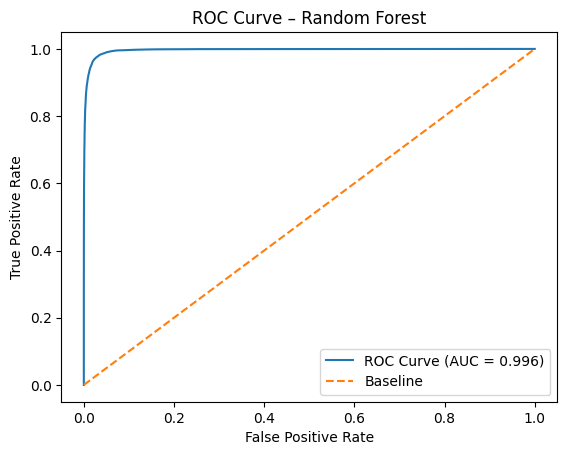

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Get probability scores
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

# Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.3f})")

# Plot baseline (random model)
plt.plot([0, 1], [0, 1], linestyle='--', label="Baseline")

# Labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest")

plt.legend(loc="lower right")
plt.show()

In [ ]:
import streamlit as st
import pandas as pd
import joblib

# Load saved model and tools
model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")
features = joblib.load("features.pkl")

# App Title
st.title("Asteroid Hazard Prediction System")

st.write("Enter asteroid details to predict hazard status.")

# User Inputs
diameter_min = st.number_input("Estimated Diameter Min (km)", value=0.1)
diameter_max = st.number_input("Estimated Diameter Max (km)", value=0.3)
velocity = st.number_input("Relative Velocity (km/hr)", value=40000)
miss_distance = st.number_input("Miss Distance (km)", value=500000)
magnitude = st.number_input("Absolute Magnitude", value=22.0)

# Create Input Data
input_data = pd.DataFrame([{
    'estimated_diameter_min': diameter_min,
    'estimated_diameter_max': diameter_max,
    'relative_velocity': velocity,
    'miss_distance': miss_distance,
    'absolute_magnitude': magnitude
}])

# Match Feature Columns
for col in features:
    if col not in input_data.columns:
        input_data[col] = 0

input_data = input_data[features]

# Prediction Button
if st.button("Predict Hazard"):

    # Scale input
    scaled_data = scaler.transform(input_data)

    # Predict
    prediction = model.predict(scaled_data)
    probability = model.predict_proba(scaled_data)

    # Output
    if prediction[0] == 1:
        st.error("Hazardous Asteroid")
    else:
        st.success("Non-Hazardous Asteroid")

    st.write(f"**Hazard Probability:** {probability[0][1]:.2f}")

2026-03-28 07:14:20.912 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 07:14:20.922 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 07:14:20.930 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 07:14:20.941 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 07:14:20.952 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 07:14:20.960 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 07:14:20.973 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 07:14:20.976 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
pip install streamlit;
